<a href="https://colab.research.google.com/github/nexageapps/AI/blob/main/Basic/B08%20-%20Regularization%20and%20Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 8: Regularization and Overfitting


## Learning Objectives
- Understand overfitting vs underfitting
- Master L1 and L2 regularization
- Implement dropout for neural networks
- Learn early stopping techniques
- Apply data augmentation strategies

## Why This Matters

**The Fundamental Trade-off:**
- **Underfitting:** Model too simple, poor performance on both training and test
- **Overfitting:** Model too complex, great on training but poor on test
- **Just Right:** Generalizes well to unseen data

**Real-World Impact:**
- Medical diagnosis: Overfitted model fails on new patients
- Stock prediction: Memorizes past patterns, fails on future
- Image recognition: Works in lab, fails in production

## Prerequisites
- Completed L1-L7
- Understanding of neural networks and evaluation metrics

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

print(f"TensorFlow version: {tf.__version__}")
np.random.seed(42)
tf.random.set_seed(42)

2026-03-26 23:09:07.025183: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2


## 1. Understanding Overfitting

### The Problem:
Model learns training data **too well**, including noise and outliers.

### Signs of Overfitting:
- Training accuracy >> Test accuracy
- Training loss keeps decreasing, validation loss increases
- Model performs poorly on new data

### Causes:
1. Too many parameters (complex model)
2. Too little training data
3. Training for too long
4. No regularization

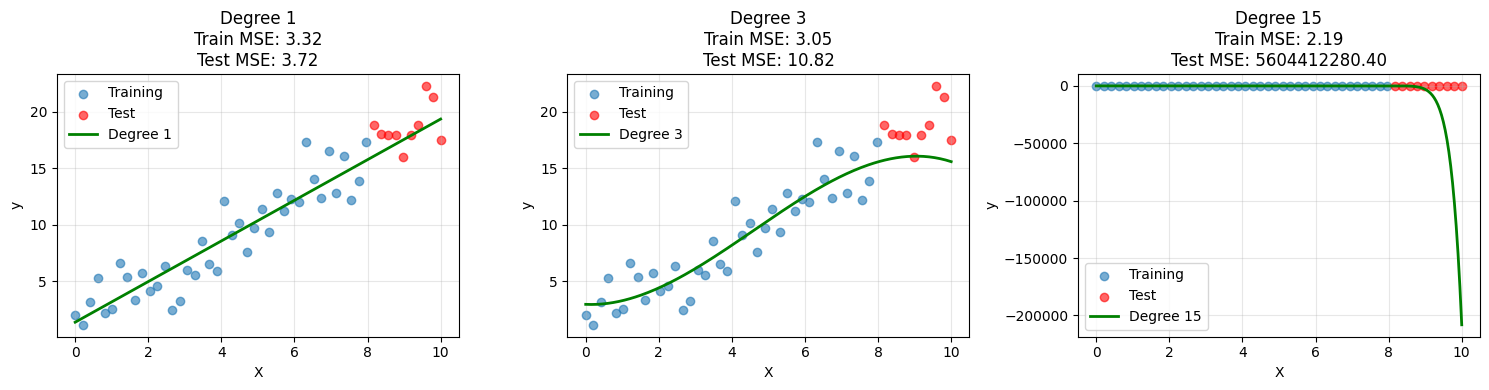

Degree 1 (Underfitting): High error on both train and test
Degree 3 (Just Right): Good balance
Degree 15 (Overfitting): Low train error, high test error


In [2]:
# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 10, 50)
y = 2 * X + 1 + np.random.randn(50) * 2  # Linear with noise

# Split data
X_train, X_test = X[:40], X[40:]
y_train, y_test = y[:40], y[40:]

# Fit models with different complexities
degrees = [1, 3, 15]  # Linear, cubic, high-degree polynomial

plt.figure(figsize=(15, 4))
for i, degree in enumerate(degrees):
    # Fit polynomial
    coeffs = np.polyfit(X_train, y_train, degree)
    poly = np.poly1d(coeffs)
    
    # Predict
    X_plot = np.linspace(0, 10, 200)
    y_plot = poly(X_plot)
    
    # Calculate errors
    train_error = np.mean((poly(X_train) - y_train) ** 2)
    test_error = np.mean((poly(X_test) - y_test) ** 2)
    
    # Plot
    plt.subplot(1, 3, i + 1)
    plt.scatter(X_train, y_train, label='Training', alpha=0.6)
    plt.scatter(X_test, y_test, label='Test', alpha=0.6, color='red')
    plt.plot(X_plot, y_plot, 'g-', linewidth=2, label=f'Degree {degree}')
    plt.title(f'Degree {degree}\nTrain MSE: {train_error:.2f}\nTest MSE: {test_error:.2f}', fontsize=12)
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Degree 1 (Underfitting): High error on both train and test")
print("Degree 3 (Just Right): Good balance")
print("Degree 15 (Overfitting): Low train error, high test error")

## 2. L2 Regularization (Ridge)

### Concept:
Add penalty for large weights to loss function:

```
Loss = Original Loss + λ * Σ(w²)
```

### Effect:
- Shrinks weights toward zero
- Prevents any single weight from becoming too large
- Smoother decision boundaries

### When to Use:
- Most common regularization
- Works well for most problems
- Keeps all features

In [ ]:
# Generate classification data
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, 
                          n_redundant=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model without regularization
model_no_reg = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(20,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='No_Regularization')

# Model with L2 regularization
model_l2 = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(20,),
                kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(64, activation='relu',
                kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(32, activation='relu',
                kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(1, activation='sigmoid')
], name='L2_Regularization')

# Compile both
for model in [model_no_reg, model_l2]:
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train both
print("Training without regularization...")
history_no_reg = model_no_reg.fit(X_train, y_train, epochs=50, batch_size=32,
                                  validation_split=0.2, verbose=0)

print("Training with L2 regularization...")
history_l2 = model_l2.fit(X_train, y_train, epochs=50, batch_size=32,
                          validation_split=0.2, verbose=0)

# Plot comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_no_reg.history['loss'], label='Train (No Reg)')
plt.plot(history_no_reg.history['val_loss'], label='Val (No Reg)')
plt.plot(history_l2.history['loss'], label='Train (L2)', linestyle='--')
plt.plot(history_l2.history['val_loss'], label='Val (L2)', linestyle='--')
plt.title('Loss Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_no_reg.history['accuracy'], label='Train (No Reg)')
plt.plot(history_no_reg.history['val_accuracy'], label='Val (No Reg)')
plt.plot(history_l2.history['accuracy'], label='Train (L2)', linestyle='--')
plt.plot(history_l2.history['val_accuracy'], label='Val (L2)', linestyle='--')
plt.title('Accuracy Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNotice: L2 regularization reduces overfitting (smaller gap between train and val)")

## 3. L1 Regularization (Lasso)

### Concept:
Add penalty for absolute value of weights:

```
Loss = Original Loss + λ * Σ|w|
```

### Effect:
- Drives some weights to exactly zero
- Performs feature selection
- Creates sparse models

### When to Use:
- When you want feature selection
- High-dimensional data
- Interpretability is important

In [ ]:
# Model with L1 regularization
model_l1 = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(20,),
                kernel_regularizer=regularizers.l1(0.01)),
    layers.Dense(64, activation='relu',
                kernel_regularizer=regularizers.l1(0.01)),
    layers.Dense(32, activation='relu',
                kernel_regularizer=regularizers.l1(0.01)),
    layers.Dense(1, activation='sigmoid')
], name='L1_Regularization')

model_l1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training with L1 regularization...")
history_l1 = model_l1.fit(X_train, y_train, epochs=50, batch_size=32,
                          validation_split=0.2, verbose=0)

# Compare weight distributions
weights_no_reg = model_no_reg.layers[0].get_weights()[0].flatten()
weights_l1 = model_l1.layers[0].get_weights()[0].flatten()
weights_l2 = model_l2.layers[0].get_weights()[0].flatten()

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(weights_no_reg, bins=50, alpha=0.7)
plt.title('No Regularization\nWeight Distribution', fontsize=12)
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.subplot(1, 3, 2)
plt.hist(weights_l1, bins=50, alpha=0.7, color='orange')
plt.title('L1 Regularization\nWeight Distribution (Sparse)', fontsize=12)
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.subplot(1, 3, 3)
plt.hist(weights_l2, bins=50, alpha=0.7, color='green')
plt.title('L2 Regularization\nWeight Distribution (Shrunk)', fontsize=12)
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nWeights near zero:")
print(f"  No Reg: {np.sum(np.abs(weights_no_reg) < 0.01)}")
print(f"  L1: {np.sum(np.abs(weights_l1) < 0.01)} (more sparse)")
print(f"  L2: {np.sum(np.abs(weights_l2) < 0.01)}")

## 4. Dropout

### Concept:
Randomly "drop" (set to zero) a fraction of neurons during training.

### Effect:
- Prevents co-adaptation of neurons
- Creates ensemble effect
- Forces network to learn robust features

### Best Practices:
- Typical rate: 0.2-0.5
- Apply after dense layers
- Only active during training
- Higher dropout for larger networks

In [ ]:
# Model with dropout
model_dropout = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(20,)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
], name='Dropout')

model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training with dropout...")
history_dropout = model_dropout.fit(X_train, y_train, epochs=50, batch_size=32,
                                   validation_split=0.2, verbose=0)

# Compare all methods
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_no_reg.history['val_loss'], label='No Reg', linewidth=2)
plt.plot(history_l1.history['val_loss'], label='L1', linewidth=2)
plt.plot(history_l2.history['val_loss'], label='L2', linewidth=2)
plt.plot(history_dropout.history['val_loss'], label='Dropout', linewidth=2)
plt.title('Validation Loss Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_no_reg.history['val_accuracy'], label='No Reg', linewidth=2)
plt.plot(history_l1.history['val_accuracy'], label='L1', linewidth=2)
plt.plot(history_l2.history['val_accuracy'], label='L2', linewidth=2)
plt.plot(history_dropout.history['val_accuracy'], label='Dropout', linewidth=2)
plt.title('Validation Accuracy Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Early Stopping

### Concept:
Stop training when validation performance stops improving.

### Parameters:
- **monitor:** Metric to watch (val_loss, val_accuracy)
- **patience:** Epochs to wait before stopping
- **restore_best_weights:** Use best model, not last

### Benefits:
- Prevents overfitting
- Saves training time
- Automatic hyperparameter

In [ ]:
# Model with early stopping
model_early = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(20,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='Early_Stopping')

model_early.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Training with early stopping...")
history_early = model_early.fit(
    X_train, y_train,
    epochs=100,  # Set high, early stopping will stop earlier
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

print(f"\nStopped at epoch: {len(history_early.history['loss'])}")
print(f"Best validation loss: {min(history_early.history['val_loss']):.4f}")

## 6. Combining Regularization Techniques

Best practice: Use multiple techniques together!

In [ ]:
# Best practices model
model_best = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(20,),
                kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu',
                kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu',
                kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.1),
    layers.Dense(1, activation='sigmoid')
], name='Best_Practices')

model_best.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train with early stopping
print("Training with combined regularization...")
history_best = model_best.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

# Evaluate on test set
test_loss, test_acc = model_best.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

## 7. Key Takeaways

### Understanding Overfitting:
1. **Overfitting** occurs when model memorizes training data
2. **Signs:** Large gap between train and validation performance
3. **Causes:** Too complex model, too little data, too long training

### Regularization Techniques:
4. **L2 (Ridge):** Shrinks all weights, most common
5. **L1 (Lasso):** Creates sparse models, feature selection
6. **Dropout:** Randomly drops neurons, prevents co-adaptation
7. **Early Stopping:** Stops when validation stops improving

### Best Practices:
8. **Combine techniques:** L2 + Dropout + Early Stopping
9. **Start simple:** Add complexity only if needed
10. **Monitor validation:** Always use validation set
11. **Cross-validate:** Ensure results are robust
12. **More data:** Best regularization is more training data

## Next Steps (L9)
- Learn Convolutional Neural Networks (CNNs)
- Apply to image classification
- Understand convolution and pooling

## References
- Deep Learning Book Chapter 7: https://www.deeplearningbook.org/
- Dropout Paper: https://jmlr.org/papers/v15/srivastava14a.html
- Keras Regularization: https://keras.io/api/layers/regularizers/

---

## Exercises

Test your understanding with these hands-on exercises. Try to solve them before looking at the hints.


### Exercise 1: Overfitting Demonstration

Create a small dataset (50 samples) and train two models:
1. A large model (3 hidden layers, 256 units each) **without** regularization
2. The same model **with** L2 regularization and dropout

Plot training vs validation loss for both. Identify which one overfits and explain why.



In [ ]:
import tensorflow as tf
import numpy as np

# Small dataset — easy to overfit
# X = np.random.randn(50, 10).astype(np.float32)
# y = (np.sum(X[:, :3], axis=1) > 0).astype(np.float32)

# Model 1: No regularization
# Model 2: L2 + Dropout
# Train both with validation_split=0.3
# Plot training vs validation loss

# Your code here


### Exercise 2: Early Stopping Implementation

Train a neural network on MNIST and implement early stopping with `patience=3`. Record:
1. At which epoch training stopped
2. The best validation loss
3. Compare final test accuracy with and without early stopping (train for 50 epochs without it)



In [ ]:
import tensorflow as tf

# Load MNIST
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss', patience=3, restore_best_weights=True
# )

# model.fit(X_train, y_train, epochs=50, validation_split=0.2,
#           callbacks=[early_stop])

# Your code here


---

## Key Takeaways

**Relevant UoA Courses:** COMPSCI 762, COMPSCI 713

1. Overfitting: model memorizes training data, poor generalization
2. L2 regularization: L = Loss + λ·Σw² - penalizes large weights
3. L1 regularization: L = Loss + λ·Σ|w| - encourages sparsity
4. Dropout: randomly deactivate neurons during training (p=0.5 typical)
5. Early stopping: stop training when validation loss stops improving

---

## Exam Preparation Guide

### Essential Concepts for Exams

- Identify overfitting: training loss ↓, validation loss ↑
- Know effect of λ: larger λ = more regularization = simpler model
- Understand L1 vs L2: L1 → sparse weights, L2 → small weights
- Explain why dropout works: prevents co-adaptation of neurons
- Common question: Given learning curves, diagnose overfitting/underfitting

### Common Mistakes to Avoid

- ❌ Using dropout during testing (should only be during training)
- ❌ Setting λ too high (underfitting) or too low (overfitting)
- ❌ Not using validation set to detect overfitting

### Practice Problems

1. Training acc: 99%, Validation acc: 70%. What's the problem? Solutions?
2. Calculate L2 regularized loss: MSE=10, weights=[2,3,4], λ=0.1
3. Why does dropout prevent overfitting?

### How This Helps Your UoA Courses

**COMPSCI 762, COMPSCI 713:**
- Provides hands-on implementation of theoretical concepts
- Practice problems similar to exam questions
- Reinforces lecture material with code examples
- Helps build intuition for complex topics

### Study Tips

1. **Understand, Don't Memorize**: Focus on why, not just what
2. **Practice Calculations**: Work through problems by hand
3. **Connect to Theory**: Link code to mathematical formulations
4. **Teach Others**: Explaining concepts solidifies understanding
5. **Review Regularly**: Spaced repetition improves retention

### Exam Question Types

- **Conceptual**: Explain why/how something works
- **Calculation**: Compute outputs, gradients, shapes
- **Comparison**: Compare approaches, trade-offs
- **Application**: Design solution for given problem
- **Debugging**: Identify and fix issues

---


---

## Learning Progress Tracker

Use this section to track your learning progress for this lesson.

### Completion Status
- [ ] Lesson completed
- [ ] All code cells executed successfully
- [ ] Understood all key concepts
- [ ] Completed practice exercises (if any)

### Dates
- **First Completed:** ____/____/____
- **Last Reviewed:** ____/____/____
- **Next Review:** ____/____/____ (Recommended: 1 week, 1 month, 3 months)

### Understanding Level
Rate your understanding (1-5): _____ / 5

- 1 = Need to review completely
- 2 = Understood basics, need more practice
- 3 = Good understanding, minor gaps
- 4 = Strong understanding, can explain to others
- 5 = Mastered, can apply in projects

### Notes & Reflections
```
Write your notes here:
- What concepts were challenging?
- What was interesting or surprising?
- How can you apply this in projects?
- Questions to explore further?




```

### Key Concepts to Remember (B08)
- [ ] Overfitting and underfitting
- [ ] L1 and L2 regularization
- [ ] Dropout technique
- [ ] Early stopping

---